In [ ]:
import matplotlib.pyplot as plt
from scipy import stats
import os, json, math
import seaborn as sns
import pandas as pd
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# __Speed stats and plots__

In [ ]:
SPEED_CSV = '/content/drive/MyDrive/llp_col_project/experimental_results/results_raw_speed.csv'
OUT_DIR   = '/content/drive/MyDrive/llp_col_project/experimental_results/analysis_speed'
os.makedirs(OUT_DIR, exist_ok=True)

In [ ]:
df = pd.read_csv(SPEED_CSV)

In [ ]:
assert {'method_tag','area_km2','offset','seed','epoch','r','rmse','stage'}.issubset(df.columns)
df['area_km2'] = df['area_km2'].astype(float)
df['offset'] = df['offset'].astype(float)
df['seed'] = df['seed'].astype(int)
df['epoch'] = df['epoch'].astype(int)

In [ ]:

TARGET_AREAS = [1, 32, 64, 1024]
df = df[df['area_km2'].isin(TARGET_AREAS)].copy()

df['method_tag'] = df['method_tag'].replace({
    'swav_pretrained_ft':'swav',
    'swav_pretrained':'swav',
    'pretrained':'swav'
}).fillna(df['method_tag'])

In [ ]:
def first_epoch_reaching_r(final_r, r_series, target=0.90):
    thr = target * final_r
    ok = r_series[r_series >= thr]
    return int(ok.index[0]) if len(ok) else None

def first_epoch_reaching_rmse(final_rmse, rmse_series, margin=0.05):
    thr = (1.0 + margin) * final_rmse
    ok = rmse_series[rmse_series <= thr]
    return int(ok.index[0]) if len(ok) else None

def normalized_auc_r(r_series, final_r):
    if final_r <= 0:
        return np.nan
    return float(np.mean(np.clip(r_series.values / final_r, 0, np.inf)))

def normalized_auc_rmse(rmse_series, final_rmse):
    safe = np.where(rmse_series.values > 0, rmse_series.values, np.nan)
    arr = final_rmse / safe
    return float(np.nanmean(arr))

In [ ]:
rows = []
gb = df.groupby(['dataset_tag','method_tag','area_km2','offset','seed'])
for (ds, method, area, off, seed), dfg in gb:
    dfg = dfg.sort_values('epoch')
    r_final    = float(dfg['r'].iloc[-1])
    rmse_final = float(dfg['rmse'].iloc[-1])

    r_series    = dfg.set_index('epoch')['r']
    rmse_series = dfg.set_index('epoch')['rmse']

    e90  = first_epoch_reaching_r(r_final, r_series, target=0.90)
    e95  = first_epoch_reaching_r(r_final, r_series, target=0.95)
    erm5 = first_epoch_reaching_rmse(rmse_final, rmse_series, margin=0.05)

    naucr   = normalized_auc_r(r_series, r_final)
    naucrm  = normalized_auc_rmse(rmse_series, rmse_final)

    rows.append({
        'dataset_tag': ds,
        'method_tag' : method,
        'area_km2'   : area,
        'offset'     : off,
        'seed'       : seed,
        'r_final'    : r_final,
        'rmse_final' : rmse_final,
        'E@90_r'     : e90,
        'E@95_r'     : e95,
        'E@5%_rmse'  : erm5,
        'nAUC_r'     : naucr,
        'nAUC_rmse'  : naucrm
    })

speed_df = pd.DataFrame(rows)
speed_df.to_csv(os.path.join(OUT_DIR, 'speed_metrics.csv'), index=False)
speed_df.head()

,dataset_tag,method_tag,area_km2,offset,seed,r_final,rmse_final,E@90_r,E@95_r,E@5%_rmse,nAUC_r,nAUC_rmse
0,Tolima,scratch,1.0,0.0,333,0.895807,0.175102,5,6,6,0.769704,0.752369
1,Tolima,scratch,1.0,0.0,666,0.903426,0.138451,6,6,10,0.765754,0.628467
2,Tolima,scratch,1.0,0.5,333,0.915576,0.122856,8,8,10,0.749570,0.593272
3,Tolima,scratch,1.0,0.5,666,0.864241,0.209761,5,5,5,0.802322,1.007316
4,Tolima,scratch,32.0,0.0,333,0.906799,0.117546,5,5,9,0.791904,0.723998


In [ ]:
sns.set(style='whitegrid', context='talk')

def plot_learning_curves(area, seed, off):
    dfa = df[(df['area_km2']==area) & (df['seed']==seed) & (df['offset']==off)].copy()
    if dfa.empty:
        print(f"No data for area={area}, seed={seed}, offset={off}")
        return
    dfa = dfa.sort_values('epoch')
    fig, axes = plt.subplots(1, 2, figsize=(14,5))
    # r
    ax = axes[0]
    sns.lineplot(data=dfa, x='epoch', y='r', hue='method_tag', marker='o', ax=ax)
    ax.set_title(f'Pearson r vs Epoch | Area={area} km² | seed={seed} | offset={off}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Pearson r')
    ax.legend(title='Method')
    # RMSE
    ax = axes[1]
    sns.lineplot(data=dfa, x='epoch', y='rmse', hue='method_tag', marker='o', ax=ax)
    ax.set_title(f'RMSE vs Epoch | Area={area} km² | seed={seed} | offset={off}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('RMSE')
    ax.legend(title='Method')
    plt.tight_layout()
    fname = f'lc_area{int(area)}_seed{seed}_off{off}.png'.replace('.0_','.0_')
    plt.savefig(os.path.join(OUT_DIR, fname), dpi=150)
    plt.show()

# ejemplos de ploteo
for A in TARGET_AREAS:
    for S in [333, 666]:
        for O in [0.0, 0.5]:
            plot_learning_curves(A, S, O)

In [ ]:
def agg_speed(dfm):
    g = dfm.groupby(['dataset_tag','method_tag','area_km2','offset'], as_index=False).agg(
        E90_mean=('E@90_r','mean'), E90_std=('E@90_r','std'),
        E95_mean=('E@95_r','mean'), E95_std=('E@95_r','std'),
        ERM5_mean=('E@5%_rmse','mean'), ERM5_std=('E@5%_rmse','std'),
        nAUC_r_mean=('nAUC_r','mean'), nAUC_r_std=('nAUC_r','std'),
        nAUC_rmse_mean=('nAUC_rmse','mean'), nAUC_rmse_std=('nAUC_rmse','std'),
    )
    return g

cmp = agg_speed(speed_df)
cmp.to_csv(os.path.join(OUT_DIR,'speed_metrics_agg.csv'), index=False)
cmp.head(10)

,dataset_tag,method_tag,area_km2,offset,E90_mean,E90_std,E95_mean,E95_std,ERM5_mean,ERM5_std,nAUC_r_mean,nAUC_r_std,nAUC_rmse_mean,nAUC_rmse_std
0,Tolima,scratch,1.0,0.0,5.5,0.707107,6.0,0.000000,8.0,2.828427,0.767729,0.002793,0.690418,0.087612
1,Tolima,scratch,1.0,0.5,6.5,2.121320,6.5,2.121320,7.5,3.535534,0.775946,0.037301,0.800294,0.292774
2,Tolima,scratch,32.0,0.0,5.5,0.707107,5.5,0.707107,8.0,1.414214,0.752747,0.055376,0.740510,0.023352
3,Tolima,scratch,32.0,0.5,6.0,1.414214,6.5,0.707107,9.0,1.414214,0.808140,0.119582,0.685964,0.038597
4,Tolima,scratch,64.0,0.0,5.0,0.000000,5.0,0.000000,6.5,0.707107,0.841066,0.055877,0.733878,0.103250
5,Tolima,scratch,64.0,0.5,4.5,0.707107,5.0,0.000000,8.0,2.828427,0.840913,0.025407,0.731638,0.014024
6,Tolima,scratch,1024.0,0.0,5.5,0.707107,5.5,0.707107,6.0,0.000000,0.777394,0.008592,0.985447,0.200500
7,Tolima,scratch,1024.0,0.5,5.0,1.414214,6.0,1.414214,7.5,3.535534,0.731519,0.256865,0.577702,0.131851
8,Tolima,swav,1.0,0.0,3.0,0.000000,4.0,1.414214,8.0,2.828427,0.941066,0.001837,0.777436,0.013576
9,Tolima,swav,1.0,0.5,3.0,0.000000,3.5,0.707107,8.0,2.828427,0.944103,0.005842,0.794061,0.023002


/tmp/ipython-input-301/3483802577.py:33: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(
/tmp/ipython-input-301/3483802577.py:33: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.

  ax = sns.barplot(


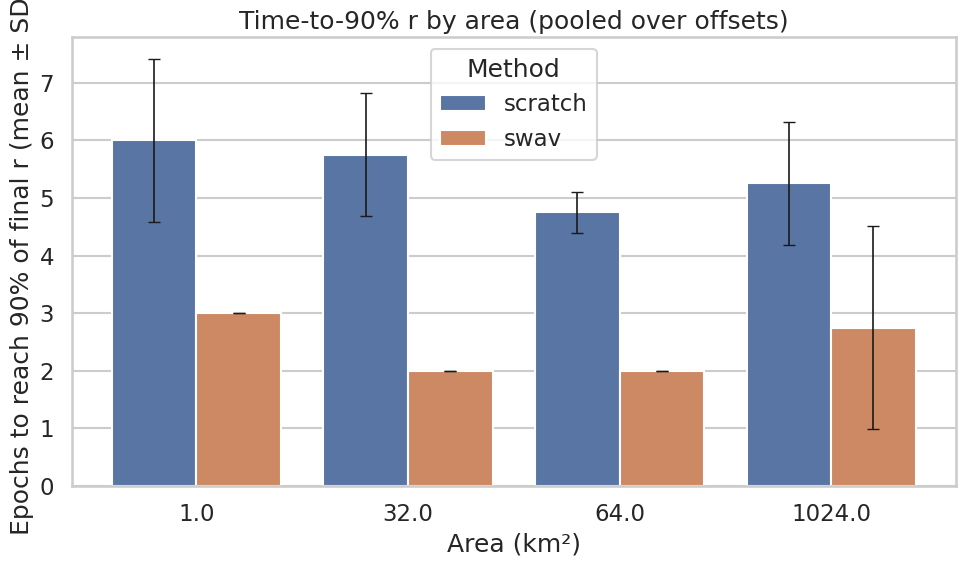

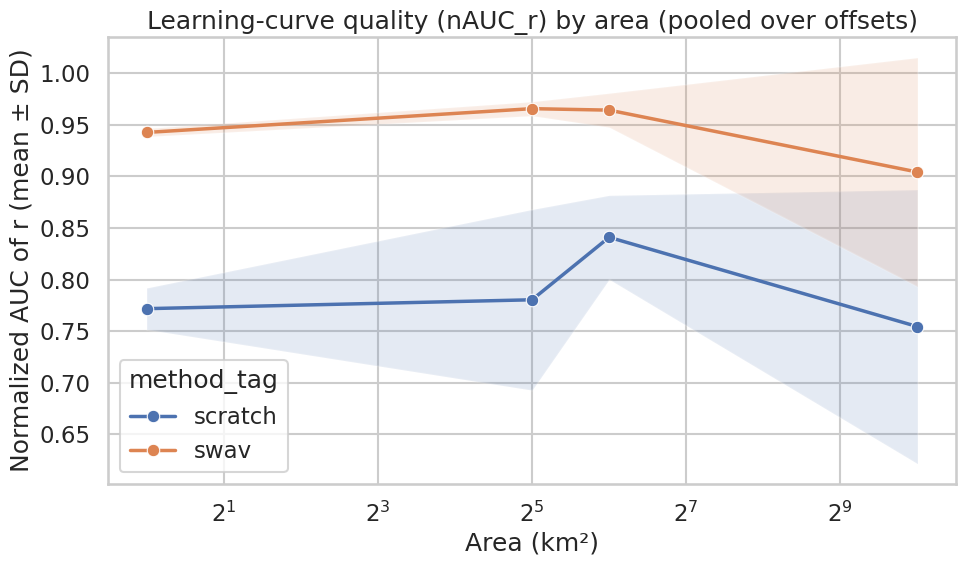

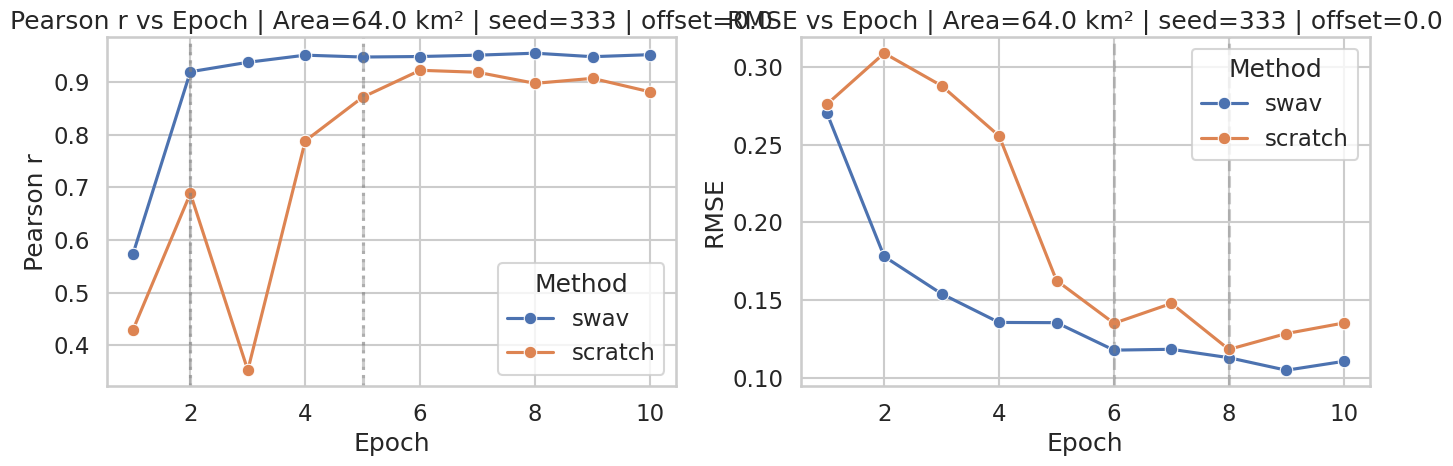

/tmp/ipython-input-301/3483802577.py:123: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(
/tmp/ipython-input-301/3483802577.py:123: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.

  ax = sns.barplot(


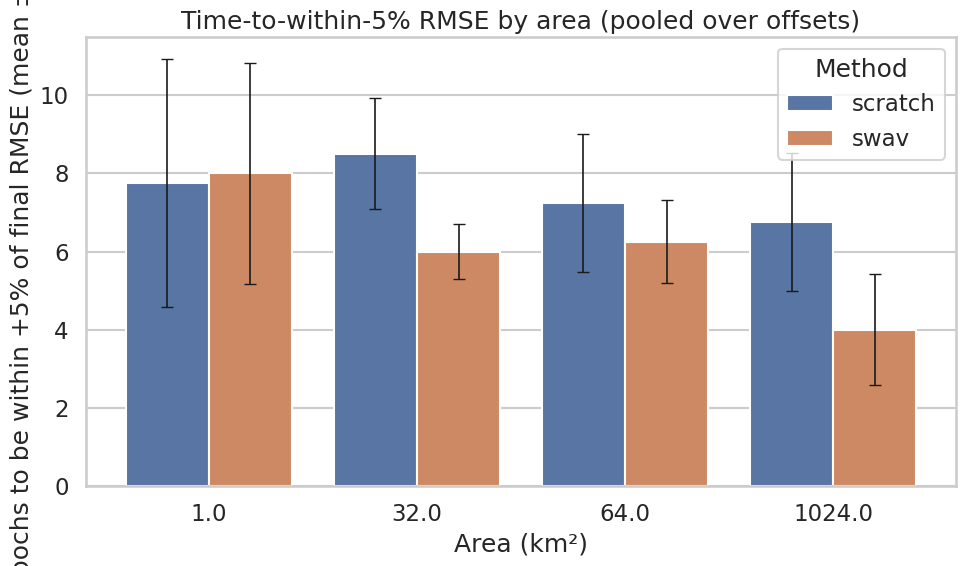

In [ ]:
sns.set(style='whitegrid', context='talk')

def pool_over_offsets(cmp_df):
    pooled = (
        cmp_df
        .groupby(['dataset_tag','method_tag','area_km2'], as_index=False)
        .agg(
            E90_mean=('E90_mean','mean'),
            E90_std =('E90_std','mean'),
            E95_mean=('E95_mean','mean'),
            E95_std =('E95_std','mean'),
            ERM5_mean=('ERM5_mean','mean'),
            ERM5_std =('ERM5_std','mean'),
            nAUC_r_mean=('nAUC_r_mean','mean'),
            nAUC_r_std =('nAUC_r_std','mean'),
            nAUC_rmse_mean=('nAUC_rmse_mean','mean'),
            nAUC_rmse_std =('nAUC_rmse_std','mean'),
        )
    )
    return pooled

cmp_pooled = pool_over_offsets(cmp)

def sort_area(series):
    return sorted(series.unique(), key=float)
plt.figure(figsize=(10,6))
order = sort_area(cmp_pooled['area_km2'])
ax = sns.barplot(
    data=cmp_pooled,
    x='area_km2', y='E90_mean', hue='method_tag', order=order,
    capsize=.15, errwidth=1.5, ci=None
)
for i, row in cmp_pooled.iterrows():
    xlocs = [j for j, a in enumerate(order) if a == row['area_km2']]
    if not xlocs: continue
    x = xlocs[0]
for patch, (_, row) in zip(ax.patches, cmp_pooled.iterrows()):
    x = patch.get_x() + patch.get_width()/2
    y = patch.get_height()
    std = row['E90_std'] if not np.isnan(row['E90_std']) else 0.0
    ax.errorbar(x, y, yerr=std, ecolor='k', elinewidth=1.2, capsize=4, fmt='none')

ax.set_xlabel('Area (km²)')
ax.set_ylabel('Epochs to reach 90% of final r (mean ± SD)')
ax.set_title('Time-to-90% r by area (pooled over offsets)')
ax.legend(title='Method')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'paper_E90r_vs_area.png'), dpi=150)
plt.show()

plt.figure(figsize=(10,6))
ax = sns.lineplot(
    data=cmp_pooled, x='area_km2', y='nAUC_r_mean', hue='method_tag',
    marker='o', linewidth=2.5
)

for method in cmp_pooled['method_tag'].unique():
    sub = cmp_pooled[cmp_pooled['method_tag']==method].sort_values('area_km2')
    x = sub['area_km2'].values.astype(float)
    y = sub['nAUC_r_mean'].values
    sd = sub['nAUC_r_std'].values
    plt.fill_between(x, y - sd, y + sd, alpha=0.15)

plt.xscale('log', base=2)
plt.xlabel('Area (km²)')
plt.ylabel('Normalized AUC of r (mean ± SD)')
plt.title('Learning-curve quality (nAUC_r) by area (pooled over offsets)')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'paper_nAUCr_vs_area.png'), dpi=150)
plt.show()

AREA_REP, SEED_REP, OFF_REP = 64.0, 333, 0.0
dfa = df[(df['area_km2']==AREA_REP) & (df['seed']==SEED_REP) & (df['offset']==OFF_REP)].copy().sort_values('epoch')
if not dfa.empty:
    marks = []
    for method, dfg in dfa.groupby('method_tag'):
        r_final    = float(dfg['r'].iloc[-1])
        rmse_final = float(dfg['rmse'].iloc[-1])
        rs = dfg.set_index('epoch')['r']
        es = dfg.set_index('epoch')['rmse']
        e90  = first_epoch_reaching_r(r_final, rs, target=0.90)
        e95  = first_epoch_reaching_r(r_final, rs, target=0.95)
        erm5 = first_epoch_reaching_rmse(rmse_final, es, margin=0.05)
        marks.append((method, e90, e95, erm5))

    fig, axes = plt.subplots(1, 2, figsize=(14,5))
    ax = axes[0]
    sns.lineplot(data=dfa, x='epoch', y='r', hue='method_tag', marker='o', ax=ax)
    for method, e90, e95, _ in marks:
        if e90 is not None: ax.axvline(e90, color='gray', linestyle='--', alpha=0.4)
        if e95 is not None: ax.axvline(e95, color='gray', linestyle=':', alpha=0.4)
    ax.set_title(f'Pearson r vs Epoch | Area={AREA_REP} km² | seed={SEED_REP} | offset={OFF_REP}')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Pearson r'); ax.legend(title='Method')

    ax = axes[1]
    sns.lineplot(data=dfa, x='epoch', y='rmse', hue='method_tag', marker='o', ax=ax)
    for method, _, __, erm5 in marks:
        if erm5 is not None: ax.axvline(erm5, color='gray', linestyle='--', alpha=0.4)
    ax.set_title(f'RMSE vs Epoch | Area={AREA_REP} km² | seed={SEED_REP} | offset={OFF_REP}')
    ax.set_xlabel('Epoch'); ax.set_ylabel('RMSE'); ax.legend(title='Method')

    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, f'paper_learning_curves_area{int(AREA_REP)}_seed{SEED_REP}_off{OFF_REP}.png'), dpi=150)
    plt.show()
else:
    print(f"[Info] No data for area={AREA_REP}, seed={SEED_REP}, offset={OFF_REP} for representative plot.")

plt.figure(figsize=(10,6))
ax = sns.barplot(
    data=cmp_pooled,
    x='area_km2', y='ERM5_mean', hue='method_tag', order=order,
    capsize=.15, errwidth=1.5, ci=None
)
for patch, (_, row) in zip(ax.patches, cmp_pooled.iterrows()):
    x = patch.get_x() + patch.get_width()/2
    y = patch.get_height()
    std = row['ERM5_std'] if not np.isnan(row['ERM5_std']) else 0.0
    ax.errorbar(x, y, yerr=std, ecolor='k', elinewidth=1.2, capsize=4, fmt='none')

ax.set_xlabel('Area (km²)')
ax.set_ylabel('Epochs to be within +5% of final RMSE (mean ± SD)')
ax.set_title('Time-to-within-5% RMSE by area (pooled over offsets)')
ax.legend(title='Method')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'paper_E5pctRMSE_vs_area.png'), dpi=150)
plt.show()


# __Incremental grid stats and plots__

In [ ]:
RAW_CSV = '/content/drive/MyDrive/llp_col_project/experimental_results/results_raw.csv'
OUT_DIR = '/content/drive/MyDrive/llp_col_project/experimental_results/analysis_full'
FIG_DIR = os.path.join(OUT_DIR, 'figures')
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

In [ ]:
df = pd.read_csv(RAW_CSV)
assert {'dataset_tag','method_tag','area_km2','offset','seed','epoch','train_bagMSE','rmse','r','num_bags','stage'}.issubset(df.columns)

df['method_tag'] = df['method_tag'].replace({
    'swav_pretrained_ft':'swav',
    'swav_pretrained':'swav',
    'pretrained':'swav'
}).fillna(df['method_tag'])

dff = df[df['stage']=='final'].copy()
dff['area_km2'] = dff['area_km2'].astype(float)
dff['offset']   = dff['offset'].astype(float)
dff['seed']     = dff['seed'].astype(int)

agg = dff.groupby(['dataset_tag','method_tag','area_km2','offset'], as_index=False).agg(
    B=('num_bags','mean'),
    r_mean=('r','mean'), r_std=('r','std'),
    rmse_mean=('rmse','mean'), rmse_std=('rmse','std'),
    seeds_completed=('seed','nunique')
).sort_values(['dataset_tag','method_tag','area_km2','offset'])

agg.to_csv(os.path.join(OUT_DIR,'results_summary_final.csv'), index=False)
agg.head(12)


,dataset_tag,method_tag,area_km2,offset,B,r_mean,r_std,rmse_mean,rmse_std,seeds_completed
0,Tolima,scratch,1.0,0.0,5976.0,0.874040,0.053094,0.169904,0.044923,3
1,Tolima,scratch,1.0,0.5,5976.0,0.899205,0.015432,0.161969,0.033221,3
2,Tolima,scratch,4.0,0.0,1526.0,0.922104,0.007835,0.118866,0.009230,3
3,Tolima,scratch,4.0,0.5,1526.0,0.913031,0.009267,0.133720,0.012547,3
4,Tolima,scratch,16.0,0.0,396.0,0.914649,0.011159,0.126841,0.025013,3
5,Tolima,scratch,16.0,0.5,396.0,0.898053,0.026186,0.127116,0.019971,3
6,Tolima,scratch,32.0,0.0,207.0,0.903596,0.018219,0.137315,0.018787,3
7,Tolima,scratch,32.0,0.5,202.0,0.905226,0.031276,0.116275,0.027269,3
8,Tolima,scratch,64.0,0.0,105.0,0.915666,0.042527,0.109208,0.012727,3
9,Tolima,scratch,64.0,0.5,107.0,0.879387,0.029321,0.182035,0.043283,3


In [ ]:
pivot_r   = agg.pivot_table(index=['dataset_tag','area_km2','offset'], columns='method_tag', values='r_mean')
pivot_err = agg.pivot_table(index=['dataset_tag','area_km2','offset'], columns='method_tag', values='rmse_mean')

delta_df = pd.DataFrame({
    'dataset_tag': [ix[0] for ix in pivot_r.index],
    'area_km2'   : [ix[1] for ix in pivot_r.index],
    'offset'     : [ix[2] for ix in pivot_r.index],
})
if 'swav' in pivot_r.columns and 'scratch' in pivot_r.columns:
    delta_df['Δr(swav-scratch)']    = pivot_r['swav'].values - pivot_r['scratch'].values
    delta_df['ΔRMSE(swav-scratch)'] = pivot_err['swav'].values - pivot_err['scratch'].values

delta_df = delta_df.sort_values(['dataset_tag','area_km2','offset'])
delta_df.to_csv(os.path.join(OUT_DIR,'method_gaps.csv'), index=False)
delta_df.head(10)

,dataset_tag,area_km2,offset,Δr(swav-scratch),ΔRMSE(swav-scratch)
0,Tolima,1.0,0.0,0.043510,-0.044124
1,Tolima,1.0,0.5,0.016781,-0.035804
2,Tolima,4.0,0.0,0.013731,-0.001452
3,Tolima,4.0,0.5,0.021886,-0.023008
4,Tolima,16.0,0.0,0.012474,-0.010511
5,Tolima,16.0,0.5,0.025725,-0.009838
6,Tolima,32.0,0.0,0.030683,-0.025829
7,Tolima,32.0,0.5,0.012178,-0.007155
8,Tolima,64.0,0.0,0.021966,-0.005806
9,Tolima,64.0,0.5,0.036728,-0.058251


In [ ]:
off_piv_r = agg.pivot_table(index=['dataset_tag','method_tag','area_km2'], columns='offset', values='r_mean')
off_piv_e = agg.pivot_table(index=['dataset_tag','method_tag','area_km2'], columns='offset', values='rmse_mean')

sens_df = off_piv_r.copy().rename(columns={0.0:'r_off0', 0.5:'r_off05'})
sens_df['Δr(off0.5 - off0.0)'] = sens_df['r_off05'] - sens_df['r_off0']

sens_df2 = off_piv_e.copy().rename(columns={0.0:'rmse_off0', 0.5:'rmse_off05'})
sens_df['ΔRMSE(off0.5 - off0.0)'] = sens_df2['rmse_off05'] - sens_df2['rmse_off0']

sens_df.reset_index().to_csv(os.path.join(OUT_DIR,'offset_sensitivity.csv'), index=False)
sens_df.head(10)

offset                             r_off0   r_off05  Δr(off0.5 - off0.0)  \
dataset_tag method_tag area_km2                                            
Tolima      scratch    1.0       0.874040  0.899205             0.025165   
                       4.0       0.922104  0.913031            -0.009073   
                       16.0      0.914649  0.898053            -0.016596   
                       32.0      0.903596  0.905226             0.001630   
                       64.0      0.915666  0.879387            -0.036279   
                       256.0     0.918944  0.865074            -0.053871   
                       1024.0    0.793504  0.841232             0.047728   
                       2048.0    0.912911  0.905682            -0.007229   
                       4096.0    0.641717  0.906678             0.264962   
            swav       1.0       0.917551  0.915986            -0.001565   

offset                           ΔRMSE(off0.5 - off0.0)  
dataset_tag method_tag area_km2                          
Tolima      scratch    1.0                    -0.007935  
                       4.0                     0.014854  
                       16.0                    0.000275  
                       32.0                   -0.021040  
                       64.0                    0.072827  
                       256.0                  -0.010209  
                       1024.0                 -0.065672  
                       2048.0                  0.000018  
                       4096.0                 -0.028004  
            swav       1.0                     0.000384

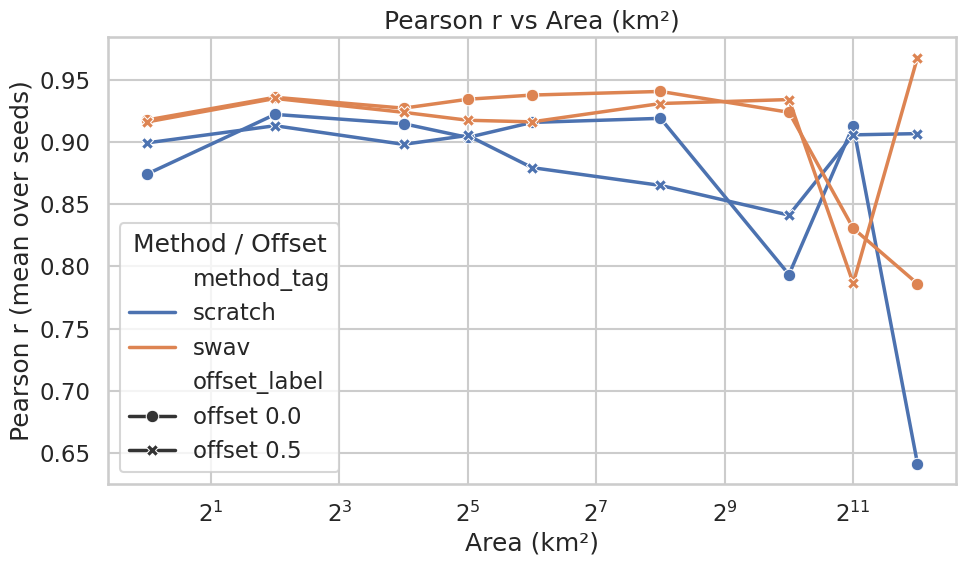

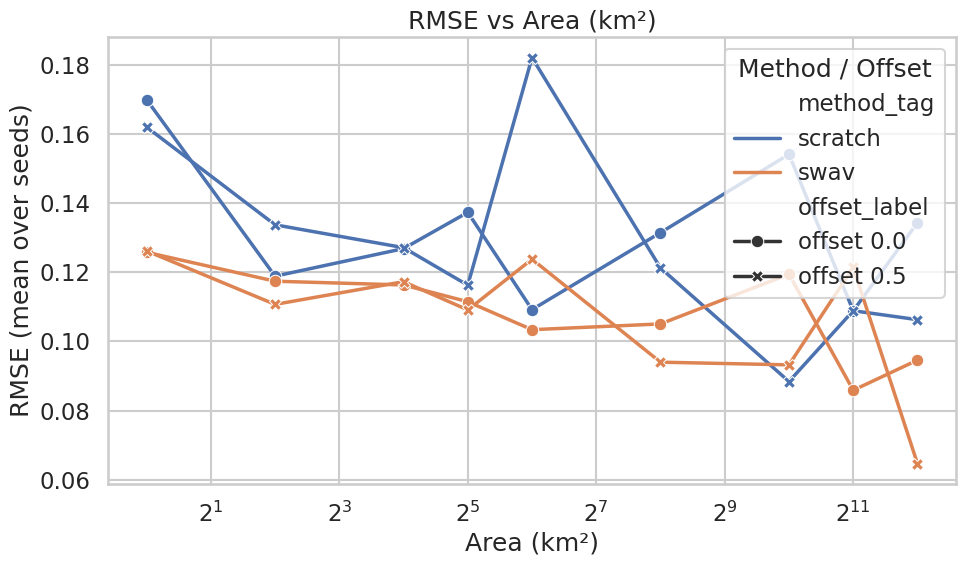

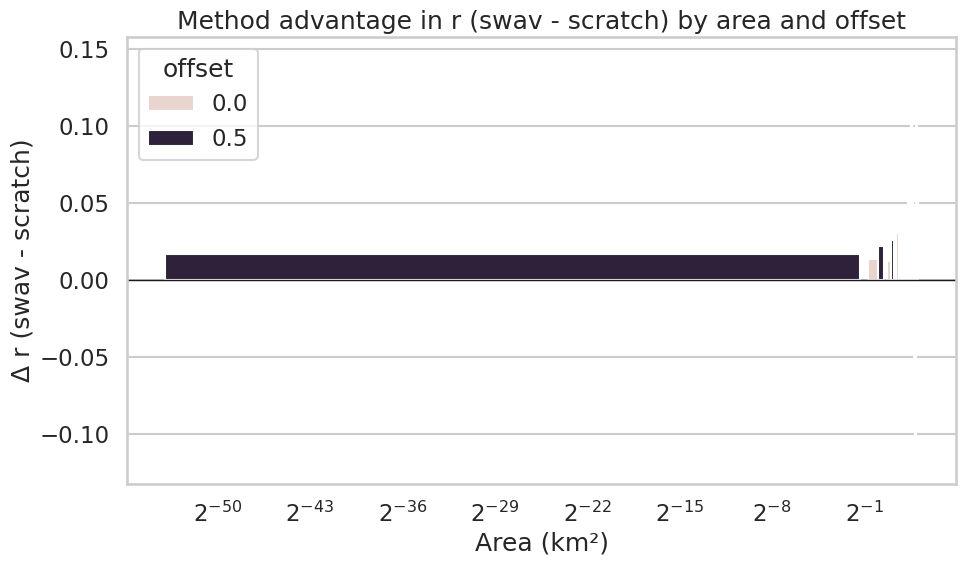

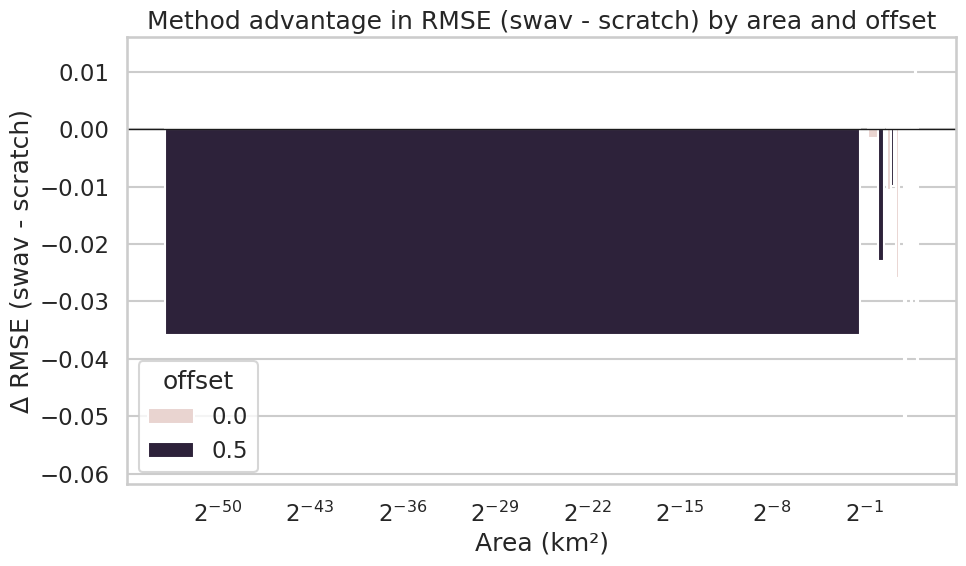

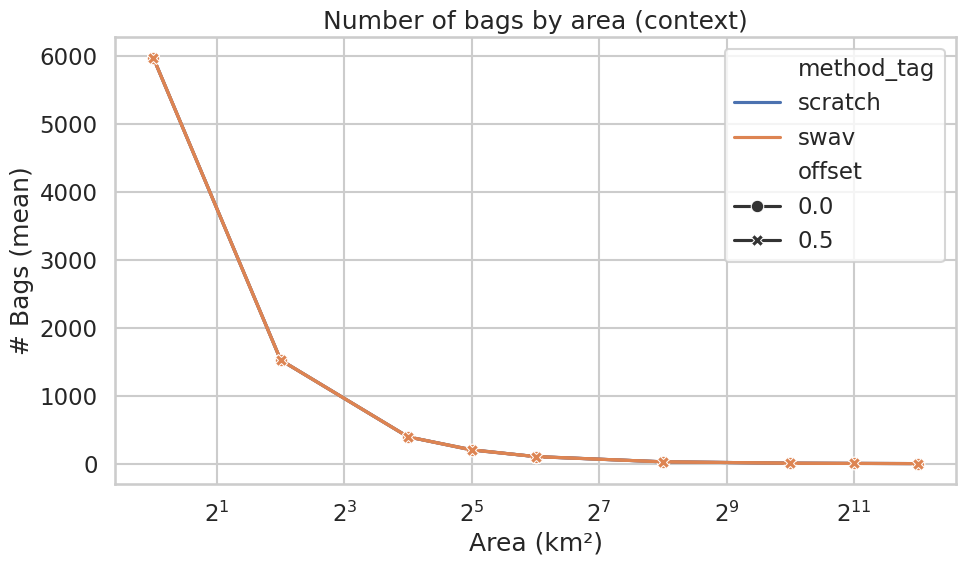

In [ ]:
sns.set(style='whitegrid', context='talk')

def area_order(x):
    return sorted(x.unique(), key=lambda v: float(v))

plt.figure(figsize=(10,6))
plot_df = agg.copy()
plot_df['offset_label'] = plot_df['offset'].map({0.0:'offset 0.0', 0.5:'offset 0.5'})
sns.lineplot(data=plot_df, x='area_km2', y='r_mean', hue='method_tag', style='offset_label',
             markers=True, dashes=False, linewidth=2.5)
plt.xscale('log', base=2)
plt.xlabel('Area (km²)')
plt.ylabel('Pearson r (mean over seeds)')
plt.title('Pearson r vs Area (km²)')
plt.legend(title='Method / Offset')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'r_vs_area.png'), dpi=150)
plt.show()

plt.figure(figsize=(10,6))
sns.lineplot(data=plot_df, x='area_km2', y='rmse_mean', hue='method_tag', style='offset_label',
             markers=True, dashes=False, linewidth=2.5)
plt.xscale('log', base=2)
plt.xlabel('Area (km²)')
plt.ylabel('RMSE (mean over seeds)')
plt.title('RMSE vs Area (km²)')
plt.legend(title='Method / Offset')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'rmse_vs_area.png'), dpi=150)
plt.show()

dd = delta_df.dropna()
plt.figure(figsize=(10,6))
sns.barplot(data=dd, x='area_km2', y='Δr(swav-scratch)', hue='offset')
plt.xscale('log', base=2)
plt.axhline(0, color='k', linewidth=1)
plt.xlabel('Area (km²)')
plt.ylabel('Δ r (swav - scratch)')
plt.title('Method advantage in r (swav - scratch) by area and offset')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'delta_r_swav_minus_scratch.png'), dpi=150)
plt.show()

plt.figure(figsize=(10,6))
sns.barplot(data=dd, x='area_km2', y='ΔRMSE(swav-scratch)', hue='offset')
plt.xscale('log', base=2)
plt.axhline(0, color='k', linewidth=1)
plt.xlabel('Area (km²)')
plt.ylabel('Δ RMSE (swav - scratch)')
plt.title('Method advantage in RMSE (swav - scratch) by area and offset')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'delta_rmse_swav_minus_scratch.png'), dpi=150)
plt.show()

plt.figure(figsize=(10,6))
sns.lineplot(data=agg, x='area_km2', y='B', hue='method_tag', style='offset',
             markers=True, dashes=False)
plt.xscale('log', base=2)
plt.xlabel('Area (km²)')
plt.ylabel('# Bags (mean)')
plt.title('Number of bags by area (context)')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'bags_vs_area.png'), dpi=150)
plt.show()

In [ ]:
plt.figure(figsize=(10,6))
plot_df = agg.copy()
plot_df['offset_label'] = plot_df['offset'].map({0.0:'offset 0.0', 0.5:'offset 0.5'})
sns.lineplot(data=plot_df, x='area_km2', y='r_mean', hue='method_tag', style='offset_label',
             markers=True, dashes=False, linewidth=2.5)
plt.xscale('log', base=2)
plt.xlabel('Area (km²)'); plt.ylabel('Pearson r (mean over seeds)')
plt.title('Pearson r vs Area (km²)'); plt.legend(title='Method / Offset')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'paper_r_vs_area.png'), dpi=300)
plt.close()

plt.figure(figsize=(10,6))
sns.lineplot(data=plot_df, x='area_km2', y='rmse_mean', hue='method_tag', style='offset_label',
             markers=True, dashes=False, linewidth=2.5)
plt.xscale('log', base=2)
plt.xlabel('Area (km²)'); plt.ylabel('RMSE (mean over seeds)')
plt.title('RMSE vs Area (km²)'); plt.legend(title='Method / Offset')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'paper_rmse_vs_area.png'), dpi=300)
plt.close()

dd = delta_df.dropna()
plt.figure(figsize=(10,6))
sns.barplot(data=dd, x='area_km2', y='Δr(swav-scratch)', hue='offset')
plt.xscale('log', base=2); plt.axhline(0, color='k', linewidth=1)
plt.xlabel('Area (km²)'); plt.ylabel('Δ r (swav - scratch)')
plt.title('Method advantage in r by area and offset')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'paper_delta_r_swav_minus_scratch.png'), dpi=300)
plt.close()

plt.figure(figsize=(10,6))
sns.barplot(data=dd, x='area_km2', y='ΔRMSE(swav-scratch)', hue='offset')
plt.xscale('log', base=2); plt.axhline(0, color='k', linewidth=1)
plt.xlabel('Area (km²)'); plt.ylabel('Δ RMSE (swav - scratch)')
plt.title('Method advantage in RMSE by area and offset')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'paper_delta_rmse_swav_minus_scratch.png'), dpi=300)
plt.close()

heat = (sens_df.reset_index()
        if isinstance(sens_df.index, pd.MultiIndex) else sens_df.copy())
heat = heat[['method_tag','area_km2','Δr(off0.5 - off0.0)']].copy()
heat_piv = heat.pivot(index='method_tag', columns='area_km2', values='Δr(off0.5 - off0.0)')
plt.figure(figsize=(12,3.8))
sns.heatmap(heat_piv, annot=True, fmt=".3f", cmap='RdBu', center=0)
plt.xlabel('Area (km²)'); plt.ylabel('Method'); plt.title('Offset sensitivity: Δr (0.5 - 0.0)')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'paper_offset_sensitivity_heatmap.png'), dpi=300)
plt.close()

plt.figure(figsize=(10,6))
sns.lineplot(data=agg, x='area_km2', y='B', hue='method_tag', style='offset', markers=True, dashes=False)
plt.xscale('log', base=2)
plt.xlabel('Area (km²)'); plt.ylabel('# Bags (mean)')
plt.title('Number of bags by area')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'paper_bags_vs_area.png'), dpi=300)
plt.close()


/tmp/ipython-input-301/3243878261.py:60: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(
/tmp/ipython-input-301/3243878261.py:60: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.

  ax = sns.barplot(


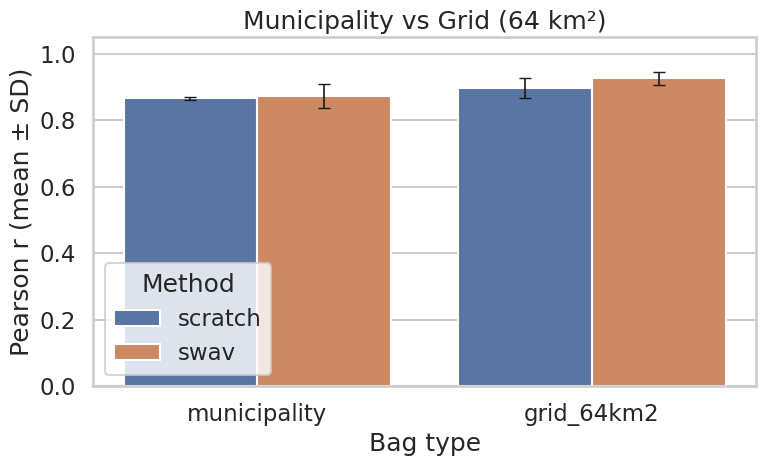

/tmp/ipython-input-301/3243878261.py:82: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(
/tmp/ipython-input-301/3243878261.py:82: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.

  ax = sns.barplot(


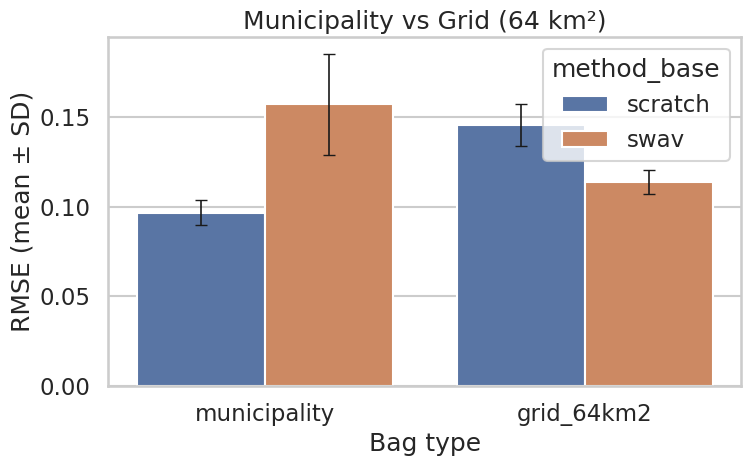

In [ ]:
MUNI_CSV = '/content/drive/MyDrive/llp_col_project/experimental_results/results_raw_muni.csv'
GRID_SUM = '/content/drive/MyDrive/llp_col_project/experimental_results/analysis_full/results_summary_final.csv'
OUT_DIR  = '/content/drive/MyDrive/llp_col_project/experimental_results/analysis_full/figures'
os.makedirs(OUT_DIR, exist_ok=True)

muni = pd.read_csv(MUNI_CSV)
grid = pd.read_csv(GRID_SUM)

muni = muni[muni['stage']=='final'].copy()
muni['method_base'] = np.where(muni['method_tag'].str.contains('swav'), 'swav', 'scratch')

muni_agg = (
    muni.groupby(['dataset_tag','method_base'], as_index=False)
        .agg(
            r_mean=('r','mean'), r_std=('r','std'),
            rmse_mean=('rmse','mean'), rmse_std=('rmse','std'),
            B_test=('num_bags_test','mean'),
            seeds=('seed','nunique')
        )
)
muni_agg['bags_type'] = 'municipality'

g64 = grid[grid['area_km2']==64.0].copy()
g64['method_base'] = g64['method_tag']
g64_pool = (
    g64.groupby(['dataset_tag','method_base','area_km2'], as_index=False)
       .agg(
           r_mean=('r_mean','mean'),
           r_std =('r_std','mean'),
           rmse_mean=('rmse_mean','mean'),
           rmse_std =('rmse_std','mean'),
           B_test=('B','mean'),
           seeds=('seeds_completed','mean')
       )
)
g64_pool['bags_type'] = 'grid_64km2'

cmp_df = pd.concat([
    muni_agg[['dataset_tag','method_base','r_mean','r_std','rmse_mean','rmse_std','B_test','seeds','bags_type']],
    g64_pool[['dataset_tag','method_base','r_mean','r_std','rmse_mean','rmse_std','B_test','seeds','bags_type']]
], ignore_index=True)

cmp_df.to_csv(os.path.join(OUT_DIR, 'paper_muni_vs_grid64_summary.csv'), index=False)

sns.set(style='whitegrid', context='talk')

plt.figure(figsize=(8,5))
ax = sns.barplot(
    data=cmp_df, x='bags_type', y='r_mean', hue='method_base',
    capsize=.15, errwidth=1.5, ci=None
)
for patch, (_, row) in zip(ax.patches, cmp_df.iterrows()):
    x = patch.get_x() + patch.get_width()/2
    y = patch.get_height()
    std = 0.0 if np.isnan(row['r_std']) else row['r_std']
    ax.errorbar(x, y, yerr=std, ecolor='k', elinewidth=1.2, capsize=4, fmt='none')

ax.set_xlabel('Bag type')
ax.set_ylabel('Pearson r (mean ± SD)')
ax.set_title('Municipality vs Grid (64 km²)')
ax.set_ylim(0, 1.05)
plt.legend(title='Method')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'paper_muni_vs_grid64_r.png'), dpi=300)
plt.show()

plt.figure(figsize=(8,5))
ax = sns.barplot(
    data=cmp_df, x='bags_type', y='rmse_mean', hue='method_base',
    capsize=.15, errwidth=1.5, ci=None
)
for patch, (_, row) in zip(ax.patches, cmp_df.iterrows()):
    x = patch.get_x() + patch.get_width()/2
    y = patch.get_height()
    std = 0.0 if np.isnan(row['rmse_std']) else row['rmse_std']
    ax.errorbar(x, y, yerr=std, ecolor='k', elinewidth=1.2, capsize=4, fmt='none')

ax.set_xlabel('Bag type')
ax.set_ylabel('RMSE (mean ± SD)')
ax.set_title('Municipality vs Grid (64 km²)')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'paper_muni_vs_grid64_rmse.png'), dpi=300)
plt.show()

# __Stats__

In [ ]:
RAW_CSV = '/content/drive/MyDrive/llp_col_project/experimental_results/results_raw.csv'
OUT_DIR = '/content/drive/MyDrive/llp_col_project/experimental_results/analysis_stats'
os.makedirs(OUT_DIR, exist_ok=True)

PRIMARY_METRICS = ['r', 'rmse']
WRITE_LATEX = True
LATEX_PATH = os.path.join(OUT_DIR, 'ttest_anova_by_area.tex')

def hedges_g(x, y):
    """
    Hedges' g (small-sample corrected Cohen's d) for two independent groups.
    Returns g and its sign follows (mean_x - mean_y).
    """
    x, y = np.asarray(x), np.asarray(y)
    nx, ny = len(x), len(y)
    if nx < 2 or ny < 2:
        return np.nan
    sx2, sy2 = x.var(ddof=1), y.var(ddof=1)
    sp = np.sqrt(((nx-1)*sx2 + (ny-1)*sy2) / (nx + ny - 2)) if (nx + ny - 2) > 0 else np.nan
    d = (x.mean() - y.mean()) / sp if sp and sp > 0 else np.nan
    J = 1 - (3 / (4*(nx + ny) - 9)) if (nx + ny) > 3 else 1.0
    return d * J

def eta_squared_anova(groups):
    """
    Eta-squared for one-way ANOVA: SS_between / SS_total.
    `groups` is a list of 1-D arrays (each group).
    """
    # Flatten to vector with group means
    all_vals = np.concatenate(groups) if len(groups) else np.array([])
    if all_vals.size < 3:
        return np.nan
    grand_mean = np.mean(all_vals)
    ss_total = np.sum((all_vals - grand_mean)**2)
    ss_between = 0.0
    for g in groups:
        ss_between += len(g) * (np.mean(g) - grand_mean)**2
    return ss_between / ss_total if ss_total > 0 else np.nan

def fdr_bh(pvals, alpha=0.05):
    """
    Benjamini–Hochberg FDR correction.
    Returns: adjusted p-values (same order), and mask of significance at alpha.
    """
    p = np.asarray(pvals, dtype=float)
    n = p.size
    order = np.argsort(p)
    ranked = p[order]
    bh = ranked * n / (np.arange(n) + 1)
    bh_adj = np.minimum.accumulate(bh[::-1])[::-1]
    padj = np.empty_like(bh_adj)
    padj[order] = np.clip(bh_adj, 0, 1)
    return padj, padj < alpha

def _assumption_checks(x, y):
    """
    Returns dict with assumption checks:
    - shapiro_x/y p-values
    - levene p-value
    """
    out = {}
    try:
        out['shapiro_x_p'] = stats.shapiro(x).pvalue if len(x) >= 3 and len(x) <= 5000 else np.nan
    except Exception:
        out['shapiro_x_p'] = np.nan
    try:
        out['shapiro_y_p'] = stats.shapiro(y).pvalue if len(y) >= 3 and len(y) <= 5000 else np.nan
    except Exception:
        out['shapiro_y_p'] = np.nan
    try:
        out['levene_p'] = stats.levene(x, y, center='mean').pvalue if (len(x) >= 2 and len(y) >= 2) else np.nan
    except Exception:
        out['levene_p'] = np.nan
    return out

def _welch_t(x, y):
    """Welch t-test, returns t, p, dof."""
    t, p = stats.ttest_ind(x, y, equal_var=False, nan_policy='omit')
    vx, vy = np.var(x, ddof=1), np.var(y, ddof=1)
    nx, ny = len(x), len(y)
    dof = (vx/nx + vy/ny)**2 / (((vx/nx)**2)/(nx-1) + ((vy/ny)**2)/(ny-1)) if nx>1 and ny>1 else np.nan
    return t, p, dof

def _anova_2groups(x, y):
    """
    One-way ANOVA on two groups (equivalent to t-test when assumptions hold).
    Returns F, p, eta2.
    """
    F, p = stats.f_oneway(x, y)
    eta2 = eta_squared_anova([np.asarray(x), np.asarray(y)])
    return F, p, eta2

def _prep_df(raw_csv):
    df = pd.read_csv(raw_csv)
    keep = df['stage'].astype(str).str.lower().eq('final')
    df = df[keep].copy()
    for col in ['area_km2', 'offset', 'seed']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    df = df[df['method_tag'].isin(['swav', 'scratch'])].copy()
    df = df[df['area_km2'] >= 0].copy()
    return df

def _collect_tests(df, group_cols, metrics=('r','rmse')):
    """
    Run Welch t-tests and ANOVA for each group (e.g., per-area or per-area/offset).
    Returns DataFrame with rows per (group, metric) and columns for tests and effect sizes.
    """
    rows = []
    grouped = df.groupby(group_cols, dropna=False)
    for gkey, gdf in grouped:
        xs = gdf[gdf['method_tag'] == 'swav']
        ys = gdf[gdf['method_tag'] == 'scratch']
        if xs.empty or ys.empty:
            continue

        for m in metrics:
            if m not in gdf.columns:
                continue
            xv = xs[m].dropna().values
            yv = ys[m].dropna().values
            if len(xv) < 2 or len(yv) < 2:
                t, p_t, dof = np.nan, np.nan, np.nan
                F, p_F, eta2 = np.nan, np.nan, np.nan
                g_eff = np.nan
                shx, shy, lev = np.nan, np.nan, np.nan
            else:
                assm = _assumption_checks(xv, yv)
                shx, shy, lev = assm['shapiro_x_p'], assm['shapiro_y_p'], assm['levene_p']
                t, p_t, dof = _welch_t(xv, yv)
                try:
                    F, p_F, eta2 = _anova_2groups(xv, yv)
                except Exception:
                    F, p_F, eta2 = np.nan, np.nan, np.nan
                g_eff = hedges_g(xv, yv)

            row = {}
            if isinstance(gkey, tuple):
                for key_name, key_val in zip(group_cols, gkey):
                    row[key_name] = key_val
            else:
                row[group_cols[0]] = gkey

            row.update({
                'metric': m,
                'n_swav': int(len(xs)),
                'n_scratch': int(len(ys)),
                'mean_swav': float(xs[m].mean()),
                'mean_scratch': float(ys[m].mean()),
                'diff_mean': float(xs[m].mean() - ys[m].mean()),

                't_stat': float(t) if pd.notna(t) else np.nan,
                't_p': float(p_t) if pd.notna(p_t) else np.nan,
                't_dof': float(dof) if pd.notna(dof) else np.nan,
                'hedges_g': float(g_eff) if pd.notna(g_eff) else np.nan,

                'F_stat': float(F) if pd.notna(F) else np.nan,
                'F_p': float(p_F) if pd.notna(p_F) else np.nan,
                'eta_sq': float(eta2) if pd.notna(eta2) else np.nan,

                'shapiro_swav_p': float(shx) if pd.notna(shx) else np.nan,
                'shapiro_scratch_p': float(shy) if pd.notna(shy) else np.nan,
                'levene_p': float(lev) if pd.notna(lev) else np.nan,
            })
            rows.append(row)

    out = pd.DataFrame(rows)
    if out.empty:
        return out

    for m in metrics:
        mask = out['metric'].eq(m)
        pvals = out.loc[mask, 't_p'].values
        padj, sig = fdr_bh(np.where(np.isnan(pvals), 1.0, pvals), alpha=0.05)
        out.loc[mask, 't_p_adj'] = padj
        out.loc[mask, 't_sig_adj'] = sig
        pvalsF = out.loc[mask, 'F_p'].values
        padjF, sigF = fdr_bh(np.where(np.isnan(pvalsF), 1.0, pvalsF), alpha=0.05)
        out.loc[mask, 'F_p_adj'] = padjF
        out.loc[mask, 'F_sig_adj'] = sigF

    return out

def _to_latex_per_area(df_area, file_path, caption="Welch t-test and ANOVA per area (pooled offsets).", label="tab:ttest_anova_area"):
    """
    Export a compact LaTeX table per area (pooled offsets) with r and RMSE,
    showing mean±SD by method (from the test rows), Welch t (p_adj) and ANOVA (p_adj),
    plus Hedges' g / eta^2. Keep it narrow to fit one column.
    """
    cols = ['area_km2', 'metric',
            'mean_swav', 'mean_scratch',
            't_stat', 't_p_adj', 'hedges_g',
            'F_stat', 'F_p_adj', 'eta_sq']
    df_print = df_area[cols].copy()
    for c in ['mean_swav', 'mean_scratch', 't_stat', 't_p_adj', 'hedges_g', 'F_stat', 'F_p_adj', 'eta_sq']:
        if c in df_print.columns:
            df_print[c] = df_print[c].astype(float).round(4)
    lines = []
    lines.append(r'\begin{table}[h!]')
    lines.append(r'\centering')
    lines.append(r'\scriptsize')
    lines.append(r'\setlength{\tabcolsep}{4pt}')
    lines.append(r'\captionsetup{labelformat=ijimai_format,labelsep=null}')
    lines.append(rf'\caption{{{caption}}}')
    lines.append(rf'\label{{{label}}}')
    lines.append(r'\begin{tabular}{l l r r r r r r r}')
    lines.append(r'\toprule')
    lines.append(r'\textbf{Area (km$^2$)} & \textbf{Metric} & $\bar{x}_{\text{SwAV}}$ & $\bar{x}_{\text{Scratch}}$ & $t$ & $p_{\text{adj}}$ & $g$ & $F$ & $p_{\text{adj}}$ & $\eta^2$ \\')
    lines.append(r'\midrule')
    for _, row in df_print.iterrows():
        area = f"{row['area_km2']:.0f}" if pd.notna(row['area_km2']) else ''
        metric = row['metric']
        vals = [area, metric,
                f"{row['mean_swav']:.4f}",
                f"{row['mean_scratch']:.4f}",
                f"{row['t_stat']:.4f}" if pd.notna(row['t_stat']) else '',
                f"{row['t_p_adj']:.4f}" if pd.notna(row['t_p_adj']) else '',
                f"{row['hedges_g']:.4f}" if pd.notna(row['hedges_g']) else '',
                f"{row['F_stat']:.4f}" if pd.notna(row['F_stat']) else '',
                f"{row['F_p_adj']:.4f}" if pd.notna(row['F_p_adj']) else '',
                f"{row['eta_sq']:.4f}" if pd.notna(row['eta_sq']) else '']
        lines.append(' & '.join(vals) + r' \\')
    lines.append(r'\bottomrule')
    lines.append(r'\end{tabular}')
    lines.append(r'\end{table}')
    with open(file_path, 'w') as f:
        f.write('\n'.join(lines))
def run_swav_vs_scratch_tests():
    print("[Info] Loading final results from:", RAW_CSV)
    df = _prep_df(RAW_CSV)
    by_area = _collect_tests(df, group_cols=['area_km2'], metrics=PRIMARY_METRICS)
    path_area = os.path.join(OUT_DIR, 'ttest_anova_by_area.csv')
    by_area.to_csv(path_area, index=False)
    print(f"[Saved] {path_area}  ({len(by_area)} rows)")
    if WRITE_LATEX and not by_area.empty:
        _to_latex_per_area(by_area, LATEX_PATH,
                           caption="Welch t-test and ANOVA per area (pooled offsets).",
                           label="tab:ttest_anova_area")
        print(f"[Saved] {LATEX_PATH}")
    by_area_off = _collect_tests(df, group_cols=['area_km2', 'offset'], metrics=PRIMARY_METRICS)
    path_area_off = os.path.join(OUT_DIR, 'ttest_anova_by_area_offset.csv')
    by_area_off.to_csv(path_area_off, index=False)
    print(f"[Saved] {path_area_off}  ({len(by_area_off)} rows)")
    def _star(p):
        return '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    if not by_area.empty:
        print("\n[Summary] Significant (FDR) per-area comparisons:")
        for m in PRIMARY_METRICS:
            sub = by_area[(by_area['metric']==m) & (by_area['t_p_adj']<0.05)]
            if not sub.empty:
                print(f"  Metric={m}: areas=", sorted(sub['area_km2'].unique().tolist()))
        show = by_area.sort_values(['metric','t_p_adj']).head(8).copy()
        show['t_q'] = show['t_p_adj'].apply(_star)
        show['F_q'] = show['F_p_adj'].apply(_star)
        print(show[['area_km2','metric','mean_swav','mean_scratch','t_stat','t_p_adj','t_q','hedges_g','F_stat','F_p_adj','F_q','eta_sq']])
if __name__ == "__main__":
    try:
        run_swav_vs_scratch_tests()
    except Exception as e:
        print("[Error] Statistical tests failed:", e)

[Info] Loading final results from: /content/drive/MyDrive/llp_col_project/experimental_results/results_raw.csv
[Saved] /content/drive/MyDrive/llp_col_project/experimental_results/analysis_stats/ttest_anova_by_area.csv  (18 rows)
[Saved] /content/drive/MyDrive/llp_col_project/experimental_results/analysis_stats/ttest_anova_by_area.tex
[Saved] /content/drive/MyDrive/llp_col_project/experimental_results/analysis_stats/ttest_anova_by_area_offset.csv  (36 rows)

[Summary] Significant (FDR) per-area comparisons:
  Metric=r: areas= [4.0]
    area_km2 metric  mean_swav  mean_scratch    t_stat   t_p_adj t_q  \
2        4.0      r   0.935376      0.917567  4.456081  0.032676   *   
4       16.0      r   0.925450      0.906351  2.178746  0.141441  ns   
6       32.0      r   0.925842      0.904411  2.092198  0.141441  ns   
10     256.0      r   0.935700      0.892009  2.256740  0.141441  ns   
14    2048.0      r   0.808600      0.909297 -2.150801  0.141441  ns   
0        1.0      r   0.916768 